# CrisisLexT6

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description


This dataset contains tweets labeled by crowdsourcing workers. Each tweet is accompanied by a label
, which is the result of the majority voting among at least 3 crowdsourcing workers.

There is one file per crisis, for each of the following disasters:

* [Sandy Hurricane 2012](https://en.wikipedia.org/wiki/Hurricane_Sandy)
* [Oklahoma Tornado Season 2013](https://en.wikipedia.org/wiki/2013_Moore_tornado)
* [West Texas Explosion 2013](https://en.wikipedia.org/wiki/West_Fertilizer_Company_explosion)
* [Alberta Floods 2013](https://en.wikipedia.org/wiki/2013_Alberta_floods)
* [Boston Bombings 2013](https://en.wikipedia.org/wiki/Boston_Marathon_bombings)
* [Queensland Floods 2013](https://en.wikipedia.org/wiki/January_2013_Eastern_Australia_floods)

On-topic/Off-topic files: `[disasters]-ontopic_offtopic.csv`

**Contents:**
Each file contains approximately 10,000 tweets. 50% of these tweets were
sampled from the geo-based sample, and 50% from the keywords-based sample.
These two samples are described in [Olteanu et al. 2014].

**Labels:**
These files contain labels indicating if a tweet is on-topic (related to
the crisis at hand), or off-topic (not related to it).

**File format:**
One tweet per line with the following comma-separated fields:
tweet id, tweet text, tweet label

### Questions/inquiries

[Olteanu et al. 2014] Alexandra Olteanu, Carlos Castillo, Fernando Diaz, Sarah Vieweg: "CrisisLex: A Lexicon for Collecting and Filtering Microblogged Communications in Crises". ICWSM 2014.

For inquiries please contact [Alexandra Olteanu](mailto:alexandra.olteanu@epfl.ch), or Carlos Castillo, or Fernando Diaz, or Sarah Vieweg.

### Version history

 * 2014-10-26: v1.0, initial release containing labeled tweets only.

## B. Overview

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisLexT6' / 'CrisisLexT6'

Loading the `2012_Sandy_Hurricane-ontopic_offtopic.csv` file

In [2]:
filepath = dataset_path / '2012_Sandy_Hurricane' / '2012_Sandy_Hurricane-ontopic_offtopic.csv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df = pd.read_csv(filepath)
df['tweet_id'] = df['tweet id'].str.strip("'").astype('int64')
df.drop(columns=['tweet id'], inplace=True)

In [3]:
df.head()

,tweet,label,tweet_id
0,I've got enough candles to supply a Mexican fa...,off-topic,262596552399396864
1,Sandy be soooo mad that she be shattering our ...,on-topic,263044104500420609
2,@ibexgirl thankfully Hurricane Waugh played it...,off-topic,263309629973491712
3,@taos you never got that magnificent case of B...,off-topic,263422851133079552
4,"I'm at Mad River Bar &amp; Grille (New York, N...",off-topic,262404311223504896


In [4]:
csv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(csv_array[:5])

Loaded 10008 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/CrisisLexT6/CrisisLexT6/2012_Sandy_Hurricane/2012_Sandy_Hurricane-ontopic_offtopic.csv
[["I've got enough candles to supply a Mexican family" 'off-topic'
  262596552399396864]
 ['Sandy be soooo mad that she be shattering our doors and shiet #HurricaneSandy'
  'on-topic' 263044104500420609]
 ['@ibexgirl thankfully Hurricane Waugh played it cool and waited this one out. Ready to go at any moment tho.'
  'off-topic' 263309629973491712]
 ['@taos you never got that magnificent case of Burgundy I sent you to thank you for your tweets?'
  'off-topic' 263422851133079552]
 ["I'm at Mad River Bar &amp; Grille (New York, NY) http://t.co/VSiZrzKP"
  'off-topic' 262404311223504896]]


## C. Preprocess

Combine all train, dev, test files from both events to one

In [5]:
import json

files = [
    {
        'filename': '2012_Sandy_Hurricane/2012_Sandy_Hurricane-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'storm',
        'event_name': '2012 Sandy Hurricane',
        'year': 2012,
    },
    {
        'filename': '2013_Alberta_Floods/2013_Alberta_Floods-ontopic_offtopic.csv',
        'country': 'Canada',
        'event_type': 'flood',
        'event_name': '2013 Alberta Floods',
        'year': 2013,
    },
    {
        'filename': '2013_Oklahoma_Tornado/2013_Oklahoma_Tornado-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'tornado',
        'event_name': '2013 Oklahoma Tornado',
        'year': 2013,
    },
    {
        'filename': '2013_Queensland_Floods/2013_Queensland_Floods-ontopic_offtopic.csv',
        'country': 'Australia',
        'event_type': 'flood',
        'event_name': '2013 Queensland Floods',
        'year': 2013,
    },

    # Do not include these two events
    # They are not natural disasters
    # {
    #     'filename': '2013_Boston_Bombings/2013_Boston_Bombings-ontopic_offtopic.csv',
    #     'country': 'US',
    #     'event_type': 'bombing',
    #     'event_name': '2013 Boston Bombings',
    #     'year': 2013,
    # },
    # {
    #     'filename': '2013_West_Texas_Explosion/2013_West_Texas_Explosion-ontopic_offtopic.csv',
    #     'country': 'US',
    #     'event_type': 'explosion',
    #     'event_name': '2013 West Texas Explosion',
    #     'year': 2013,
    # }
]

df_list = []

for file in files:
    filename = file['filename']
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f'Not found: {filepath}')
        continue

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    
    df['tweet_id'] = df['tweet id'].str.strip("'").astype('int64')
    df.drop(columns=['tweet id'], inplace=True)
    df['event_type'] = file['event_type']
    df['event_name'] = file['event_name']
    df['year'] = file['year']
    df['informative'] = df['label'].apply(lambda x: False if x == "off-topic" else True)
    df['dataset'] = 'CrisisLexT6'
    df["meta"] = df.apply(
        lambda row: {
            'file_name': filename,
        },
        axis=1,
    )
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)

merged_df.rename(columns={'tweet': 'tweet_text'}, inplace=True)
merged_df.rename(columns={'label': 'original_informative_label'}, inplace=True)
merged_df['original_humanitarian_label'] = np.nan
merged_df['humanitarian_label'] = np.nan
merged_df = merged_df[dataset_settings.dataset_extended_cols]

merged_df.head()

,tweet_id,tweet_text,informative,humanitarian_label,event_name,event_type,dataset,original_informative_label,original_humanitarian_label,year,meta
0,262596552399396864,I've got enough candles to supply a Mexican fa...,False,NaN,2012 Sandy Hurricane,storm,CrisisLexT6,off-topic,NaN,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
1,263044104500420609,Sandy be soooo mad that she be shattering our ...,True,NaN,2012 Sandy Hurricane,storm,CrisisLexT6,on-topic,NaN,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
2,263309629973491712,@ibexgirl thankfully Hurricane Waugh played it...,False,NaN,2012 Sandy Hurricane,storm,CrisisLexT6,off-topic,NaN,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
3,263422851133079552,@taos you never got that magnificent case of B...,False,NaN,2012 Sandy Hurricane,storm,CrisisLexT6,off-topic,NaN,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
4,262404311223504896,"I'm at Mad River Bar &amp; Grille (New York, N...",False,NaN,2012 Sandy Hurricane,storm,CrisisLexT6,off-topic,NaN,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...


In [6]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

# # Remove duplicates
merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 2890


tweet_text
I've got enough candles to supply a Mexican family                                                                                              1
RT @grantswilson: My heart bleeds for the families in Oklahoma. I don't even know what to say.                                                  1
RT @GABESPIEGEL: @MelanieWeeden  sees damage in her hometown of Moore, OK. #browns #cleveland @bweeden3 http://t.co/ZJ7rYOk44K                  1
SC delegation needs to listen to Rep. Tom Cole who voted for Sandy Relief Fund & will benefit from funds for tornado victims. #SChurricanes     1
RT @CBSNews: BREAKING: Okla. officials say 20 children are among at least 51 dead after massive twister ripped through Oklahoma City suburbs    1
                                                                                                                                               ..
M2i team is serving lunch to ALL close by NOW at Nellie Breen Park!! @inglewoodyyc @icacalgary #yychelps         

In [7]:
import csv
# Use QUOTE_ALL to quote all fields, ensuring newlines and special characters are properly handled
merged_df.to_csv('../data/datasets/CrisisLexT6.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifing

In [8]:
merged_df.duplicated(subset=['tweet_id']).sum()

np.int64(3)

In [9]:
merged_df.duplicated(subset=['tweet_text']).sum()

np.int64(0)

In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37174 entries, 0 to 40063
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tweet_id                     37174 non-null  int64  
 1   tweet_text                   37174 non-null  object 
 2   informative                  37174 non-null  bool   
 3   humanitarian_label           0 non-null      float64
 4   event_name                   37174 non-null  object 
 5   event_type                   37174 non-null  object 
 6   dataset                      37174 non-null  object 
 7   original_informative_label   37174 non-null  object 
 8   original_humanitarian_label  0 non-null      float64
 9   year                         37174 non-null  int64  
 10  meta                         37174 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 3.2+ MB


In [11]:
merged_df.describe(include='all')

,tweet_id,tweet_text,informative,humanitarian_label,event_name,event_type,dataset,original_informative_label,original_humanitarian_label,year,meta
count,3.717400e+04,37174,37174,0.0,37174,37174,37174,37174,0.0,37174.000000,37174
unique,NaN,37174,2,NaN,4,3,1,2,NaN,NaN,4
top,NaN,I've got enough candles to supply a Mexican fa...,True,NaN,2012 Sandy Hurricane,flood,CrisisLexT6,on-topic,NaN,NaN,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
freq,NaN,1,18769,NaN,9431,18436,37174,18769,NaN,NaN,9431
mean,3.116038e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.746301,NaN
std,3.453996e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.435133,NaN
min,2.623429e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
25%,2.634192e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
50%,3.363171e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
75%,3.479316e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN


<Axes: xlabel='informative'>

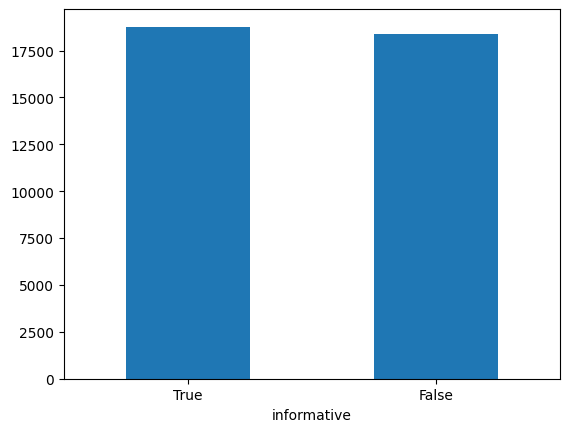

In [12]:
merged_df['informative'].value_counts(dropna=False).plot(kind='bar', rot=0)

<Axes: xlabel='event_type'>

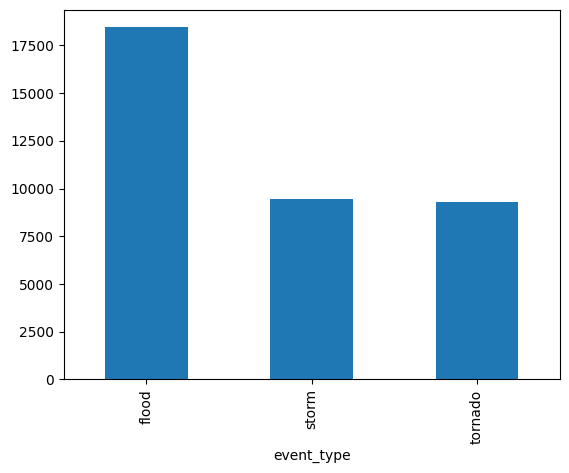

In [13]:
merged_df['event_type'].value_counts().plot(kind='bar')